In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
data = pd.read_csv('../data_sets/delhi_air_quality.csv')

In [17]:
data.shape

(1461, 12)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


In [14]:
data.duplicated().sum()

np.int64(0)

In [24]:
data.head(4)

,Date,Month,year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207


In [23]:
data.rename(columns={'Year':'year'},inplace=True)

In [28]:
data['year'].unique()

array([2021, 2022, 2023, 2024])

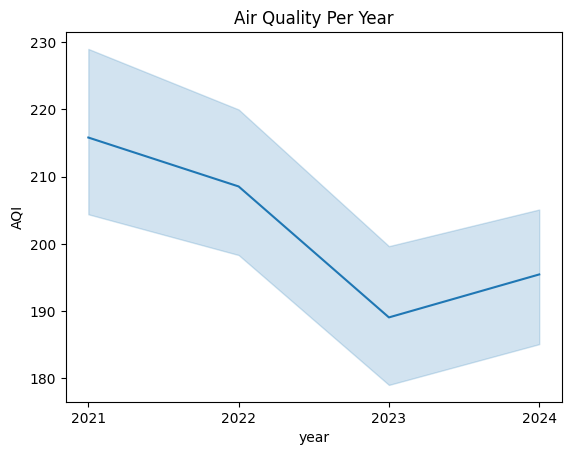

In [34]:
sns.lineplot(data,x='year',y='AQI')
plt.title('Air Quality Per Year')
plt.xticks((data['year'].unique()))
plt.show()

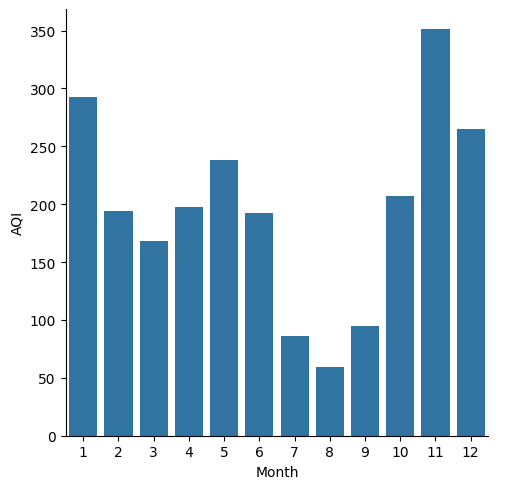

In [55]:
# month in 2024 respect to AQI

df = data.query('year==2024').groupby('Month')['AQI'].mean()
df = df.reset_index()
sns.catplot(df,x='Month',y='AQI',kind='bar')

In [140]:
# percentage of NO2 CO and SO2 in delhi Air in 2024

df = data.query('year==2024')[['NO2','SO2','CO']].sum()
px.pie(df,values=df.values,names=df.index)

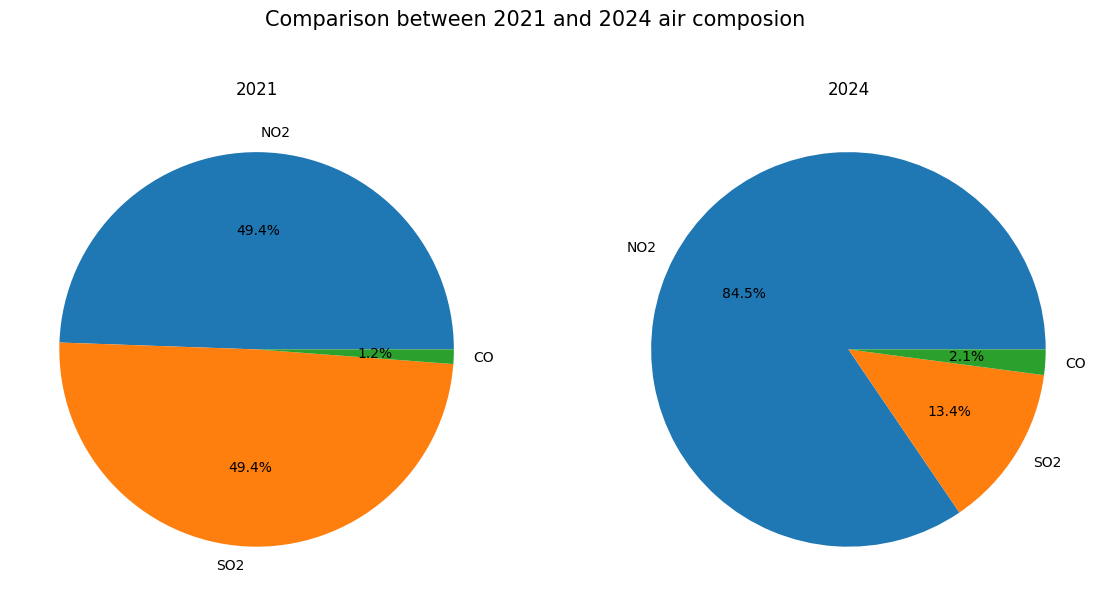

In [175]:
df2 = data.query('year==2021')[['NO2','SO2','CO']].sum()

fig,ax = plt.subplots(ncols=2,nrows=1,figsize=(14,7))

ax[1].pie(df2.values,autopct='%0.1F%%',labels=df2.index)
ax[0].pie(df.values,autopct='%0.1F%%',labels=df.index)
ax[0].set_title('2021')
ax[1].set_title('2024')
a=plt.suptitle('Comparison between 2021 and 2024 air composion',fontsize=15)
plt.show()


<Axes: xlabel='Month', ylabel='Date'>

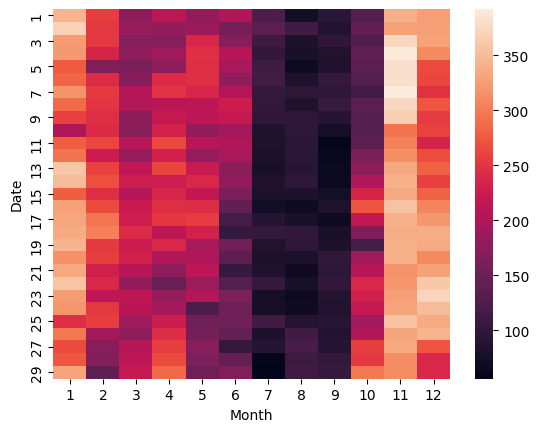

In [184]:

df = data.pivot_table(index='Date',columns='Month',values='AQI',aggfunc='mean').iloc[0:29,:]
sns.heatmap(df)

In [195]:
data.query('year==2024')['Holidays_Count'].values.sum()

np.int64(69)